In [2]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras import layers, ops
import numpy as np

In [3]:
X_normal = np.load("../data/X_normal.npy")
Y_normal = np.load("../data/Y_normal.npy")

print(X_normal.shape)
print(Y_normal.shape)

(67343, 122)
(67343, 23)


In [4]:
def Encode(input_dim = 122, latent_dim = 8):
    encoder = Sequential(
        [
            keras.Input((input_dim, )),
            layers.Dense(64, activation = 'relu', name = 'Enc_layer1', kernel_regularizer = 'l2', kernel_initializer = 'he_normal'),
            layers.Dense(32, activation = 'relu', name = 'Enc_layer2', kernel_regularizer = 'l2', kernel_initializer = 'he_normal'),
            layers.Dense(16, activation = 'relu', name = 'Enc_layer3', kernel_regularizer = 'l2', kernel_initializer = 'he_normal'),
            layers.Dense(latent_dim, activation = 'relu', name = 'Latent_Space', kernel_regularizer = 'l2', kernel_initializer = 'he_normal')
        ], name = "Encoder"
    )
    return encoder 

In [5]:
def Decode(latent_dim = 8, output_dim = 122):
    decoder = Sequential(
        [ 
            keras.Input((latent_dim, )),
            layers.Dense(16, activation = 'relu', name = 'dec_layer1', kernel_regularizer = 'l2', kernel_initializer = 'he_normal'),
            layers.Dense(32, activation = 'relu', name = 'dec_layer2', kernel_regularizer = 'l2', kernel_initializer = 'he_normal'),
            layers.Dense(64, activation = 'relu', name = 'dec_layer3', kernel_regularizer = 'l2', kernel_initializer = 'he_normal'),
            layers.Dense(output_dim, activation = 'sigmoid', name = 'Decoded_output', kernel_regularizer = 'l2', kernel_initializer = 'he_normal')
        ], name = 'Decoder'
    )
    return decoder

In [6]:
def train_autoencoder(X, epochs = 30, batch_size = 128):
    encoder = Encode(input_dim = 122, latent_dim = 8)
    decoder = Decode(latent_dim = 8, output_dim = 122)

    model = Sequential(
        [
            encoder,
            decoder
        ], name = "Model"
    )

    model.compile(optimizer = 'adam', loss = 'mse')
    
    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    model.fit(X, X, epochs = epochs, batch_size = batch_size, verbose = 1, callbacks = [early_stop])

    print("Generating final predictions with trained weights")

    X_decoded = model.predict(X)

    return X_decoded, model

In [7]:
X_decoded, model = train_autoencoder(X_normal, epochs = 30, batch_size = 128)
m = X_normal.shape[0]

reconstruction_error = np.mean(np.power(X_normal - X_decoded, 2), axis=1)

reconstruction_error.shape


Epoch 1/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 1s 468us/step - loss: 1.8632
Epoch 2/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.1626
Epoch 3/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.0816
Epoch 4/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0505
Epoch 5/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - loss: 0.0390
Epoch 6/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.0326
Epoch 7/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0283
Epoch 8/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0252
Epoch 9/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0229
Epoch 10/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - loss: 0.0213
Epoch 11/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - loss: 0.0202
Epoch 12/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - loss: 0.0194
Epoch 13/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0188
Epoch 14/30
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 0.0184
Epoch 15/30
527/527 ━━━━━━━━━

(67343,)

In [8]:
#set the threshold percentile
threshold = np.percentile(reconstruction_error, 95)

print(f"Threshold: {threshold:.4f}")

Threshold: 0.0481


In [9]:
X_all = np.load("../data/X_train.npy")
X_all_decoded = model.predict(X_all)
all_errors = np.mean(np.power(X_all - X_all_decoded, 2), axis=1)
anomalies = (all_errors > threshold).astype(int)
print(f"Flagged as anomalies: {anomalies.sum()} / {len(anomalies)}")

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 1s 167us/step
Flagged as anomalies: 52380 / 125973


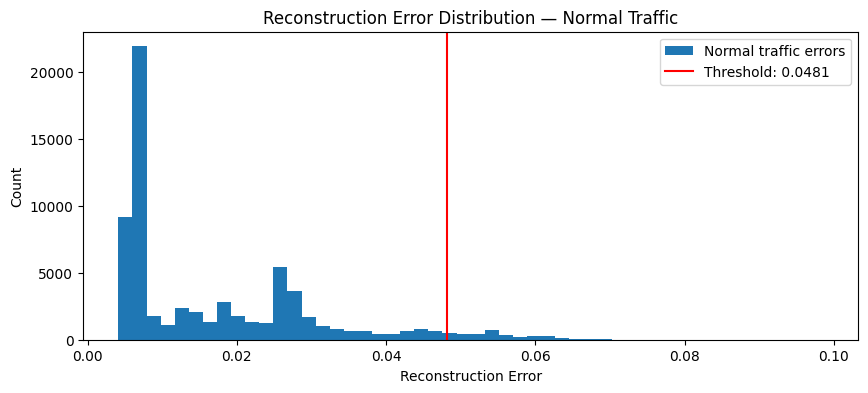

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(reconstruction_error, bins=50, label='Normal traffic errors')
plt.axvline(threshold, color='red', label=f'Threshold: {threshold:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution — Normal Traffic')
plt.legend()
plt.savefig('../data/reconstruction_error_plot.png')
plt.show()

In [11]:
model.save('../models/autoencoder.keras')
np.save('../data/threshold.npy', np.array([threshold]))
np.save('../data/all_errors.npy', all_errors)
np.save('../data/anomaly_flags.npy', anomalies)

print("Files Saved Sucessfully 👍")

Files Saved Sucessfully 👍


In [12]:
plt.savefig('../models/reconstruction_error_plot.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>